# 04 - Paper-ready results

Este notebook es la capa final para el paper: consolida tablas comparativas, figuras SVG y candidatos para revision cualitativa.

No entrena modelos ni requiere GPU. Usa los artefactos ya versionados en `outputs/results/` y `outputs/metrics/`.


## 1. Generar artefactos

Primero regeneramos el baseline TF-IDF held-out train-only para `dataset_longest_answer` y `dataset_short_answer`. Despu?s consolidamos tablas CSV/Markdown y figuras SVG bajo `outputs/paper/`.


In [7]:
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

for command in [
    [sys.executable, "-m", "src.evaluate_retrieval_heldout", "--dataset", "all"],
    [sys.executable, "-m", "src.build_paper_results"],
]:
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    print("$", " ".join(command))
    print(result.stdout)


$ c:\Users\andyd\miniconda3\envs\myenv\python.exe -m src.evaluate_retrieval_heldout --dataset all
dataset_longest_answer valid: 56 cases, chrF=0.145, BERTScore=not-computed
dataset_longest_answer test: 100 cases, chrF=0.148, BERTScore=not-computed
dataset_short_answer valid: 56 cases, chrF=0.086, BERTScore=not-computed
dataset_short_answer test: 100 cases, chrF=0.089, BERTScore=not-computed

$ c:\Users\andyd\miniconda3\envs\myenv\python.exe -m src.build_paper_results
Wrote 43 metric rows to C:\Users\andyd\Udesa\NLP\prueba1\dermavqa-paper\outputs\paper\tables
Wrote 8 main comparison rows
Wrote figures to C:\Users\andyd\Udesa\NLP\prueba1\dermavqa-paper\outputs\paper\figures



## 2. Tabla principal

La tabla principal prioriza filas case-level y usa `vlm_lora_case_avg` para el dataset enriquecido. Las filas image-level quedan en la tabla larga.


In [8]:
import csv
from pathlib import Path
from IPython.display import display, Markdown

TABLE = PROJECT_ROOT / "outputs" / "paper" / "tables" / "paper_main_test_comparison.csv"
with TABLE.open(encoding="utf-8", newline="") as handle:
    rows = list(csv.DictReader(handle))

cols = ["dataset_variant", "method", "split", "unit", "n", "sacrebleu", "chrf_corpus", "chrf_mean", "rouge_l_mean", "token_f1_mean", "bertscore_f1_mean", "mean_latency_s"]
markdown = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
for row in rows:
    markdown.append("| " + " | ".join(row.get(col, "") for col in cols) + " |")
display(Markdown("".join(markdown)))


| dataset_variant | method | split | unit | n | sacrebleu | chrf_corpus | chrf_mean | rouge_l_mean | token_f1_mean | bertscore_f1_mean | mean_latency_s || --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- || dataset_enriched | retrieval_tfidf | test | case | 100 | 8.266 | 26.990 | 0.286 | 0.216 | 0.256 | 0.716 |  || dataset_enriched | retrieval_e5 | test | case | 100 | 8.555 | 30.091 | 0.308 | 0.212 | 0.259 | 0.714 |  || dataset_enriched | retrieval_sbert | test | case | 100 | 8.795 | 29.816 | 0.309 | 0.222 | 0.269 | 0.720 |  || dataset_enriched | vlm_lora_case_avg | test | case | 100 | 5.022 | 34.532 | 0.368 | 0.250 | 0.314 | 0.737 | 46.996 || dataset_longest_answer | retrieval_tfidf_train_only | test | case | 100 | 0.462 | 13.160 | 0.148 | 0.056 | 0.072 |  | 0.001 || dataset_longest_answer | vlm_zero_shot | test | case | 100 | 0.409 | 20.548 | 0.182 | 0.072 | 0.092 | 0.628 | 26.736 || dataset_longest_answer | vlm_lora | test | case | 100 | 0.328 | 11.082 | 0.157 | 0.112 | 0.131 | 0.667 | 12.541 || dataset_short_answer | retrieval_tfidf_train_only | test | case | 100 | 0.773 | 9.958 | 0.089 | 0.013 | 0.013 |  | 0.001 |

## 3. Figuras principales

Estas figuras son SVG versionables. Se pueden insertar directo en el paper o exportar a PDF desde el navegador/editor.


main_test_chrf.svg


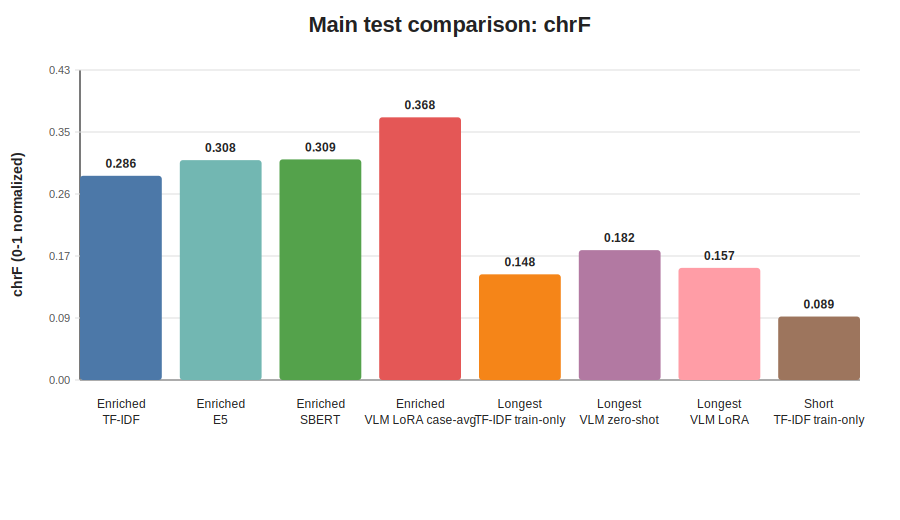

main_test_bertscore.svg


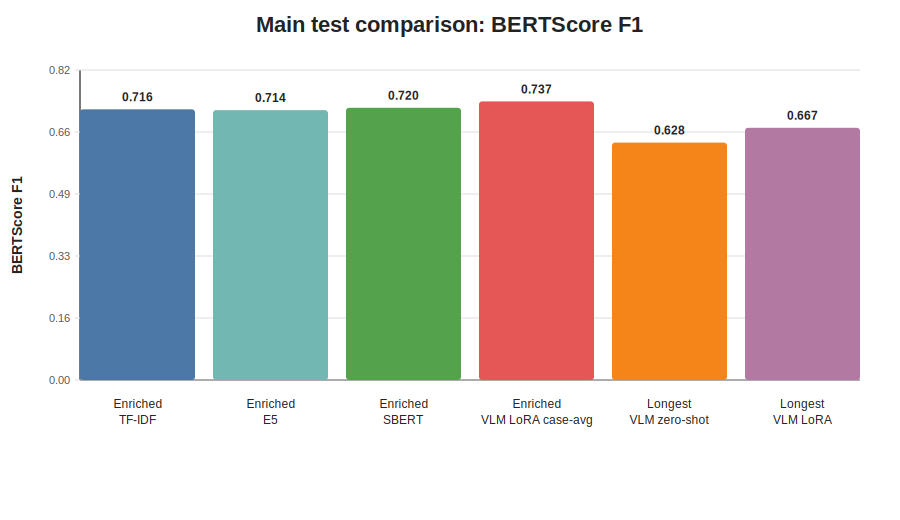

main_test_rouge_tokenf1.svg


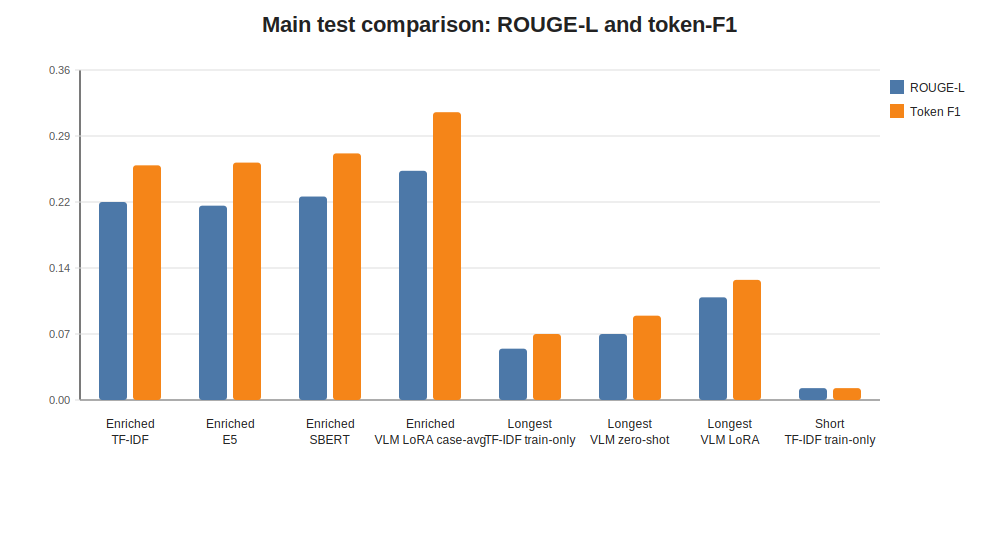

vlm_latency_vs_bertscore.svg


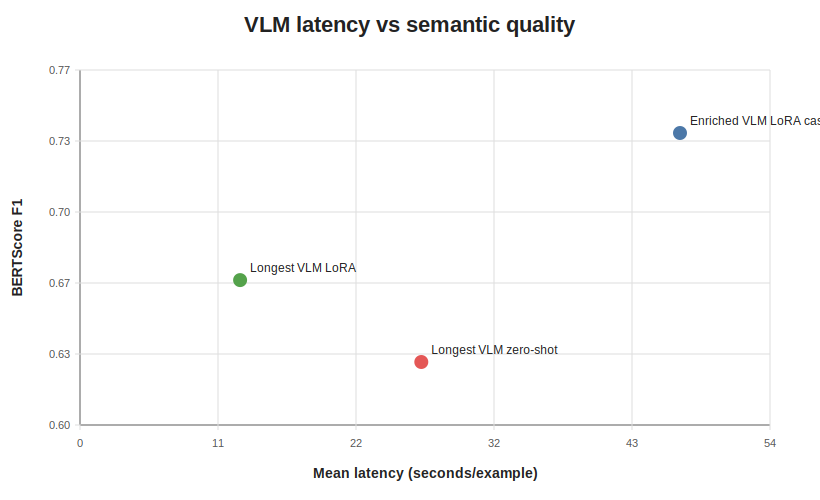

In [9]:
from IPython.display import SVG, display

fig_dir = PROJECT_ROOT / "outputs" / "paper" / "figures"
for name in [
    "main_test_chrf.svg",
    "main_test_bertscore.svg",
    "main_test_rouge_tokenf1.svg",
    "vlm_latency_vs_bertscore.svg",
]:
    print(name)
    display(SVG(filename=str(fig_dir / name)))


## 4. Figuras de soporte

Sirven para explicar datos, entrenamiento y variabilidad de errores.


dataset_split_counts.svg


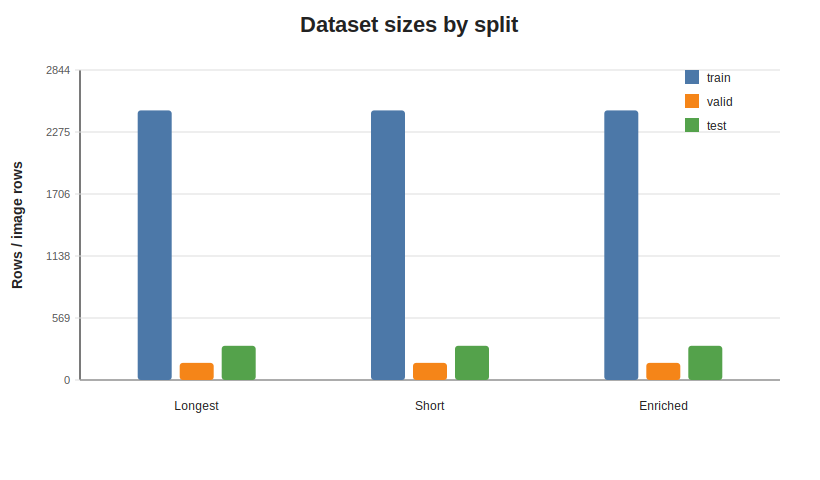

enriched_vlm_training_curve.svg


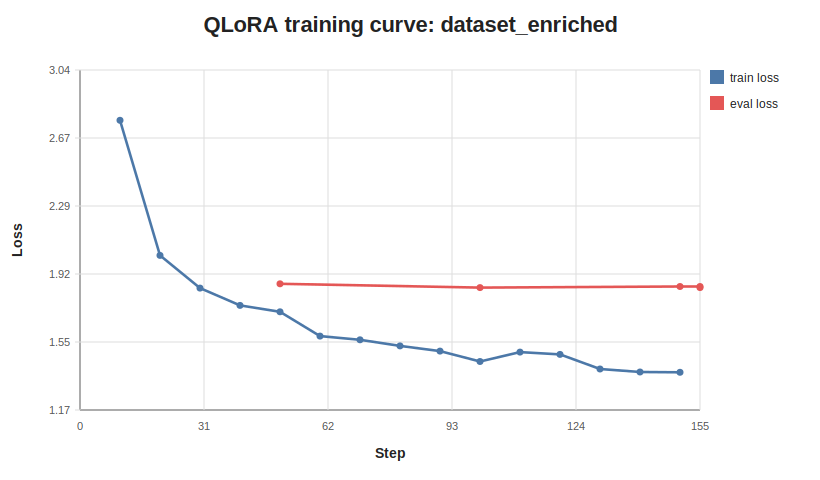

enriched_vlm_metric_distributions.svg


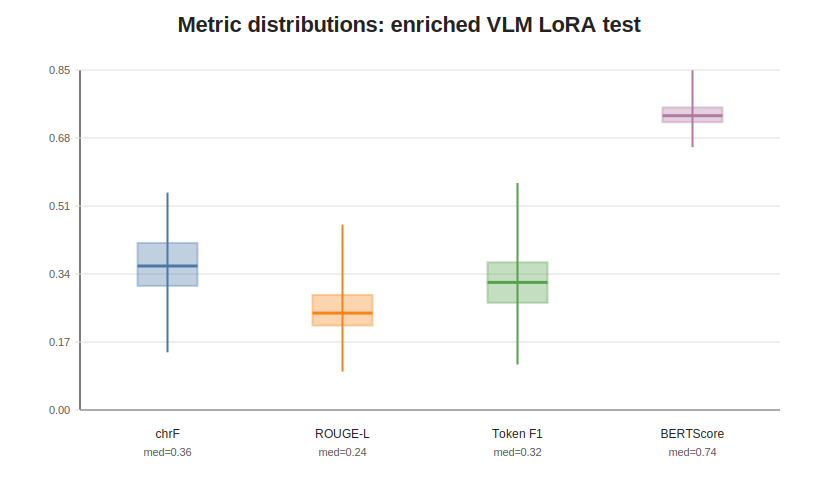

enriched_vlm_answer_length_alignment.svg


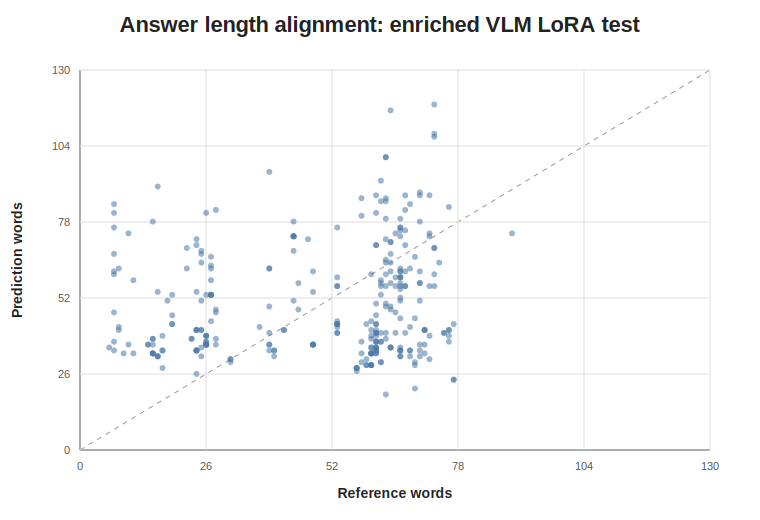

In [10]:
for name in [
    "dataset_split_counts.svg",
    "enriched_vlm_training_curve.svg",
    "enriched_vlm_metric_distributions.svg",
    "enriched_vlm_answer_length_alignment.svg",
]:
    print(name)
    display(SVG(filename=str(fig_dir / name)))


## 5. Candidatos para revision manual

La revision clinica manual todavia es pendiente. Esta tabla propone 5 casos bajos y 5 altos por BERTScore del VLM enriched en test.


In [11]:
review_path = PROJECT_ROOT / "outputs" / "paper" / "tables" / "paper_qualitative_review_candidates.md"
display(Markdown(review_path.read_text(encoding="utf-8")))


# Qualitative review candidates

Generated from `dataset_enriched/vlm_lora` test predictions.
The table includes the 5 lowest and 5 highest BERTScore F1 rows as a starting point for manual clinical review.

| bucket | encounter | image | BERTScore | reference | prediction |
| --- | --- | --- | ---: | --- | --- |
| low | ENC00935 | IMG_ENC00935_00001.jpg | 0.657 | El cuadro es compatible con liquen plano, caracterizado por pápulas planas de color rojo púrpura. | El cuadro es compatible con una erupción cutánea por medicamentos, que puede presentarse como eritema multiforme o como eritema anular centrífugo. Se sugiere realizar pruebas de sangre para detectar anemia, infección y niveles de glucosa, y considerar la posibilidad de una reacc… |
| low | ENC00950 | IMG_ENC00950_00002.jpg | 0.667 | El cuadro es compatible con varios diagnósticos diferenciales, entre los que se consideran liquen plano lineal, liquen estriado (hipopigmentado) y nevus hipopigmentado (manchas de hipopigmentación). | El cuadro es compatible con una erupción cutánea, como una erupción liquenoide por fricción o una erupción por picadura de insecto, y también podría corresponder a una verruga plana. Se sugiere realizar una prueba de patología para descartar infección fúngica y considerar la pos… |
| low | ENC00950 | IMG_ENC00950_00003.jpg | 0.670 | El cuadro es compatible con varios diagnósticos diferenciales, entre los que se consideran liquen plano lineal, liquen estriado (hipopigmentado) y nevus hipopigmentado (manchas de hipopigmentación). | El cuadro es compatible con una erupción cutánea, como una erupción liquenoide por fricción o una erupción por picadura de insecto, y también podría corresponder a una verruga plana. Se sugiere realizar una prueba de patología para descartar infección fúngica y considerar la pos… |
| low | ENC00950 | IMG_ENC00950_00001.jpg | 0.671 | El cuadro es compatible con varios diagnósticos diferenciales, entre los que se consideran liquen plano lineal, liquen estriado (hipopigmentado) y nevus hipopigmentado (manchas de hipopigmentación). | El cuadro es compatible con una erupción cutánea, como una erupción liquenoide por fricción o una erupción por picadura de insecto, y también podría corresponder a una infección fúngica. Se sugiere realizar una prueba de hongos para descartar infección fúngica y considerar la po… |
| low | ENC00938 | IMG_ENC00938_00001.jpg | 0.674 | El cuadro es compatible con necrobiosis lipoidea en los miembros inferiores. En la zona abdominal existen diferentes interpretaciones: algunas fuentes la describen como eczema, mientras que otras la consideran herpes zoster, aunque una indica que no es herpes zoster. | El cuadro es compatible con dermatitis por picadura de insecto, posiblemente de mosquito, y también se consideran como diagnósticos diferenciales la dermatitis por medicamentos, la psoriasis y la dermatitis por frío. Se sugiere realizar una prueba de patología para descartar inf… |
| high | ENC00986 | IMG_ENC00986_00001.jpg | 0.822 | El cuadro es compatible con psoriasis, aunque una respuesta indica eritema multiforme; no parece ser parapsoriasis. La mayoría sugiere confirmar el diagnóstico mediante biopsia. | El cuadro es compatible con psoriasis, aunque también se ha mencionado la posibilidad de dermatitis por contacto como diagnóstico diferencial. Se sugiere realizar una biopsia para confirmar el diagnóstico y orientar el manejo terapéutico. |
| high | ENC00986 | IMG_ENC00986_00002.jpg | 0.822 | El cuadro es compatible con psoriasis, aunque una respuesta indica eritema multiforme; no parece ser parapsoriasis. La mayoría sugiere confirmar el diagnóstico mediante biopsia. | El cuadro es compatible con psoriasis, aunque también se ha mencionado la posibilidad de dermatitis por contacto como diagnóstico diferencial. Se sugiere realizar una biopsia para confirmar el diagnóstico y orientar el manejo terapéutico. |
| high | ENC00986 | IMG_ENC00986_00004.jpg | 0.822 | El cuadro es compatible con psoriasis, aunque una respuesta indica eritema multiforme; no parece ser parapsoriasis. La mayoría sugiere confirmar el diagnóstico mediante biopsia. | El cuadro es compatible con psoriasis, aunque también se ha mencionado la posibilidad de dermatitis por contacto como diagnóstico diferencial. Se sugiere realizar una biopsia para confirmar el diagnóstico y orientar el manejo terapéutico. |
| high | ENC00986 | IMG_ENC00986_00005.jpg | 0.822 | El cuadro es compatible con psoriasis, aunque una respuesta indica eritema multiforme; no parece ser parapsoriasis. La mayoría sugiere confirmar el diagnóstico mediante biopsia. | El cuadro es compatible con psoriasis, aunque también se ha mencionado la posibilidad de dermatitis por contacto como diagnóstico diferencial. Se sugiere realizar una biopsia para confirmar el diagnóstico y orientar el manejo terapéutico. |
| high | ENC00986 | IMG_ENC00986_00003.jpg | 0.849 | El cuadro es compatible con psoriasis, aunque una respuesta indica eritema multiforme; no parece ser parapsoriasis. La mayoría sugiere confirmar el diagnóstico mediante biopsia. | El cuadro es compatible con dermatitis por contacto, aunque también se ha mencionado la posibilidad de psoriasis. Se sugiere realizar una biopsia para confirmar el diagnóstico. |

Suggested manual labels: `correct`, `partial`, `incorrect`, `unsupported_recommendation`, `hallucination`, `too_generic`.

## 6. Faltantes antes del paper final

Revisar este reporte antes de cerrar resultados.


In [12]:
missing_path = PROJECT_ROOT / "outputs" / "paper" / "tables" / "paper_missing_metrics_report.md"
display(Markdown(missing_path.read_text(encoding="utf-8")))


# Missing metrics and paper caveats

This file is generated by `python -m src.build_paper_results`.

## Missing fields

- `dataset_enriched / retrieval_e5 / test`: mean_latency_s
- `dataset_enriched / retrieval_sbert / test`: mean_latency_s
- `dataset_enriched / retrieval_tfidf / test`: mean_latency_s
- `dataset_longest_answer / retrieval_tfidf_train_only / test`: bertscore_f1_mean
- `dataset_short_answer / retrieval_tfidf_train_only / test`: bertscore_f1_mean

## Caveats

- The main table uses `dataset_enriched/vlm_lora_case_avg` for fair case-level comparison (`n=100` on test); raw image-level enriched VLM metrics remain in `paper_all_metrics_long.csv`.
- For `dataset_longest_answer` and `dataset_short_answer`, the main table uses leakage-free TF-IDF retrieval against train only when `src.evaluate_retrieval_heldout` has been run; legacy all-split retrieval rows remain in `paper_all_metrics_long.csv` for appendix context.
- Enriched case-level corpus scores concatenate de-duplicated predictions from all images in a case; this avoids oracle image selection but is not identical to averaging per-image metrics.
- BERTScore is not recomputed by this script; rows generated without BERTScore keep that field empty unless a prior metric artifact exists.
- Human clinical review labels still need a reviewer before final medical-safety claims; `paper_clinical_review_20.csv` is the structured review sheet.